# Hiruma 2023 XFEM convergence study -- 4-phase comparison

Research comparison of standard CFEM, Hiruma's PUM/XFEM enrichment, and
Schur-complement-augmented CLN model-order reduction on the canonical
skin-effect cylinder benchmark of Hiruma 2023 (IEEE TMag 59(5),
DOI 10.1109/TMAG.2023.3246629, Sec. III.A, Figs. 2-4).

**Problem**: 2D disk radius r = 0.01 m, sigma = 1e6 S/m, mu_r = 1, uniform
J0 = sigma. Governing PDE
`-div(nu grad A_z) + j*omega*sigma*A_z = J0` in Omega, `A_z = 0` on dOmega.
The solution has a sqrt(s) corner-singular (skin-effect boundary-layer)
character that makes polynomial CFEM converge slowly at high r/delta.

This notebook is **self-contained**: each phase runs on execute, writing its
JSON results (committed alongside) and figures. Promoted from
`examples/hiruma_xfem_comparison/` on 2026-06-26 with the phase scripts embedded
verbatim. (Runtime `.npz` dumps are not committed -- the JSON carries the
results per the Binary File / Data Persistence policies.)

**VERIFIED (Phase 1)**: CFEM fine (3558 DOF) matches the Bessel solution to
-0.13% at r/delta=15, while CFEM coarse (44 DOF, ~Hiruma Fig.2(b)) is -11.14%
there -- quantifying the polynomial-FE floor the XFEM enrichment targets.

## Phase 1 -- CFEM baseline

Plain continuous-FEM baseline on coarse (~Hiruma Fig.2(b)) and fine meshes; validates against the analytical Bessel solution and quantifies the polynomial-FE convergence floor when the solution has sqrt(s) corner (skin-effect boundary-layer) character.

*(source: `phase1_cfem_cylinder_baseline.py`)*

In [1]:
"""Phase 1 — CFEM baselines for the Hiruma 2023 cylinder benchmark.

Reference:  Hiruma 2023, IEEE TMag 59(5), DOI 10.1109/TMAG.2023.3246629,
            §III.A "Skin Effect in Cylindrical Conductor", Figs. 2-4.

Geometry / material (Hiruma's §III.A):
    2D disk Omega, radius r = 0.01 m
    sigma = 1e6 S/m, mu_r = 1
    Uniform current density J0 = sigma (so E_z = 1 V/m on the boundary)
    Governing: -div(nu*grad A_z) + j*omega*sigma*A_z = J0
    BC: A_z = 0 on outer circle Gamma_D
    Sweep: r/delta in [0.1, 15] (i.e. omega = 2*delta^-2/(sigma*mu))

Goal of this phase:
    Reproduce Hiruma Fig. 4 (Joule loss density and magnetic energy
    density vs r/delta) using NGSolve CFEM on TWO meshes:
        - coarse (target ~37 DOF: matches Hiruma's 37 in Fig. 2(b))
        - fine reference (target ~9489 DOF: matches Hiruma)
    Validate against the analytical Bessel solution for the disk.

Bessel reference (closed form for cylinder, J0 = sigma, A_z = 0 at r=R):
    A_z(r) = (1/(j*omega)) * (1 - I_0(gamma*r) / I_0(gamma*R))
    where gamma = sqrt(j*omega*sigma*mu_0) = (1+j)/delta
    (Derived: pde becomes (1/r)d/dr(r dA/dr) - gamma^2 A = -j*omega*mu*sigma * (sigma * 1)/(-j*omega) = ...
     simpler: H_phi from -dA_z/dr, J_z = -j*omega*sigma*A_z + J0,
              integrate J_z^2/sigma over disk for Joule loss.)

Output:
    results_phase1.npz : r_over_delta, P_coarse, P_fine, P_bessel,
                         E_coarse, E_fine, E_bessel
    plus log file with iteration counts and DOF stats
"""

import math
import numpy as np
import json
from pathlib import Path

from ngsolve import (
    Mesh, H1, BilinearForm, LinearForm, GridFunction, Preconditioner,
    grad, dx, ds, CoefficientFunction, Integrate, x, y, sqrt,
    Conj,
)
from ngsolve import TaskManager
from netgen.geom2d import SplineGeometry
from scipy.special import iv  # modified Bessel I_n (cp932-safe)


# ---------- physics constants ----------
R     = 0.01          # m, cylinder radius
SIGMA = 1.0e6         # S/m
MU0   = 4.0e-7 * math.pi
NU    = 1.0 / MU0     # magnetic reluctivity
J0    = SIGMA         # uniform external current density (A/m^2)


# =====================================================================
# Bessel analytical reference (no FE)
# =====================================================================

def bessel_reference(r_over_delta):
    """Closed-form Joule loss and magnetic energy in the disk.

    The PDE is:
        -nu * Laplacian(A) + j*omega*sigma*A = J0
    Rewriting with k^2 = -j*omega*sigma*mu_0 = -gamma^2 (gamma = (1+j)/delta):
        Laplacian(A) - gamma^2 A = -mu_0 * J0
        => A_p = mu_0 * J0 / gamma^2 = J0 / (j*omega*sigma)    (particular)
        => A_h = c * I_0(gamma * r)                            (homogeneous)
    BC A(R) = 0 forces c = -A_p / I_0(gamma R).

    Joule loss density (per unit length in z):
        P = (1/2) int_disk sigma |E_z|^2 dA, E_z = -j*omega*A_z (no V drop, 2D)
        but Hiruma uses J0 fixed so we just integrate sigma*|j*omega*A - J0/sigma|^2 / sigma.
    For our purposes report only the trend; Phase 2-3 compare absolute scales.

    Returns: dict with P_density_avg [W/m^3], E_density_avg [J/m^3].
    """
    delta = R / r_over_delta
    omega = 2.0 / (delta * delta * SIGMA * MU0)
    gamma = (1 + 1j) / delta

    A_p = J0 / (1j * omega * SIGMA)          # particular
    c   = -A_p / iv(0, gamma * R)             # so that A(R) = 0

    # Evaluate radial profile on a Gauss-Legendre quadrature
    n_quad = 200
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    r_pts  = R * 0.5 * (xi + 1)
    r_wts  = R * 0.5 * wi

    A      = A_p + c * iv(0, gamma * r_pts)   # complex A_z(r)
    E      = -1j * omega * A                   # E_z = -j w A (Coulomb gauge, V=0)
    J_tot  = SIGMA * E                          # J_z = sigma E
    # Joule loss density (per unit volume) at this r: |J|^2 / (2 sigma)
    P_r    = np.abs(J_tot) ** 2 / (2 * SIGMA)
    # Magnetic field H_phi = -(1/mu_0) dA_z/dr; B_phi = -dA_z/dr ; energy density |B|^2/(2 mu_0)
    # dA/dr = c * gamma * I_1(gamma r)
    dA_dr  = c * gamma * iv(1, gamma * r_pts)
    B      = -dA_dr
    W_r    = np.abs(B) ** 2 / (2 * MU0)

    # Disk averages: integral 2*pi*r * f(r) dr / (pi R^2)
    P_avg  = np.sum(2 * math.pi * r_pts * P_r * r_wts) / (math.pi * R * R)
    W_avg  = np.sum(2 * math.pi * r_pts * W_r * r_wts) / (math.pi * R * R)
    return {"P_density_avg": float(P_avg),
            "E_density_avg": float(W_avg),
            "omega": float(omega),
            "delta": float(delta)}


# =====================================================================
# NGSolve CFEM disk problem
# =====================================================================

def make_disk_mesh(maxh, name="disk"):
    """Generate a unit-disk mesh of radius R with prescribed maxh."""
    geo = SplineGeometry()
    geo.AddCircle((0, 0), R, leftdomain=1, rightdomain=0, bc="outer")
    return Mesh(geo.GenerateMesh(maxh=maxh))


def cfem_solve(mesh, omega):
    """Standard CFEM solve of  -nu*Laplace A + j*omega*sigma A = J0  with A|outer = 0.

    Returns (P_density_avg, E_density_avg, ndof, dict_diag).
    """
    fes = H1(mesh, order=1, complex=True, dirichlet="outer")
    u, v = fes.TnT()

    a = BilinearForm(fes, symmetric=True)
    a += NU * grad(u) * grad(v) * dx
    a += 1j * omega * SIGMA * u * v * dx
    with TaskManager():
        a.Assemble()

        f = LinearForm(fes)
        f += J0 * v * dx
        f.Assemble()

        A = GridFunction(fes)
        A.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky") * f.vec

        # Post-process: Joule loss + magnetic energy as area-averages
        E_z = -1j * omega * A
        J_z = SIGMA * E_z              # the eddy current (J0 is the source, but the actual J = -j w sigma A + 0 if E_z accounts for it; double-check)
        # Wait: -nu*Laplace(A) + j*omega*sigma*A = J0
        # => the field equation is sigma*E_z = J_z, where E_z = -j*omega*A (since V=0 in 2D).
        # However J0 is the SOURCE, NOT the eddy current.  The total current is
        #   J_total = J0 + sigma * E_z = J0 - j w sigma A.
        # Joule loss per volume = (1/2) sigma |E_z|^2 = (1/2) |J_total - J0|^2 / sigma
        # In Hiruma's setup with E_z = 1 prescribed at boundary, J0 = sigma * 1 = sigma,
        # and we want sigma |E_z|^2 / 2.
        P_cf = 0.5 * SIGMA * (E_z * Conj(E_z))   # CF for Joule loss density [W/m^3]
        B_x  = grad(A)[1]                         # B = curl(A_z e_z) = (dA/dy, -dA/dx)
        B_y  = -grad(A)[0]
        W_cf = (B_x * Conj(B_x) + B_y * Conj(B_y)) / (2 * MU0)

        # Disk area = pi*R^2; .real because the CF includes |.|^2 already (complex but real-valued)
        area = math.pi * R * R
        P_avg = Integrate(P_cf, mesh).real / area
        W_avg = Integrate(W_cf, mesh).real / area
        return P_avg, W_avg, fes.ndof, {}


# =====================================================================
# Main: sweep r/delta and tabulate
# =====================================================================

def main():
    out_dir = Path.cwd()
    print(f"output dir: {out_dir}", flush=True)
    print(f"R = {R*1000:.2f} mm, sigma = {SIGMA:.2e} S/m, mu_r = 1", flush=True)
    print()

    # Build meshes once, reuse for all frequencies
    print("=== mesh generation ===", flush=True)
    mesh_coarse = make_disk_mesh(maxh=R / 3.5,  name="coarse")  # target ~37 DOF (Hiruma 2023 §III.A)
    mesh_fine   = make_disk_mesh(maxh=R / 30.0, name="fine")    # target ~10k DOF
    print(f"  coarse: ne={mesh_coarse.ne}, nv={mesh_coarse.nv}", flush=True)
    print(f"  fine:   ne={mesh_fine.ne},   nv={mesh_fine.nv}",   flush=True)

    # Frequency sweep (15 points to start, log-spaced through skin transition)
    r_over_delta_list = np.array([0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0,
                                   7.0, 10.0, 12.0, 15.0])
    results = []
    print()
    print("=== frequency sweep (CFEM coarse + fine + Bessel) ===", flush=True)
    print(f"{'r/d':>6} {'omega':>12} {'P_bessel':>12} {'P_coarse':>12} {'P_fine':>12} "
          f"{'err_coarse':>10} {'err_fine':>10}", flush=True)
    for rd in r_over_delta_list:
        # Bessel reference
        ref = bessel_reference(rd)
        omega = ref["omega"]
        # CFEM solves
        P_c, E_c, n_c, _ = cfem_solve(mesh_coarse, omega)
        P_f, E_f, n_f, _ = cfem_solve(mesh_fine,   omega)
        # Joule loss errors vs Bessel reference
        err_c = (P_c - ref["P_density_avg"]) / ref["P_density_avg"] * 100
        err_f = (P_f - ref["P_density_avg"]) / ref["P_density_avg"] * 100
        results.append({
            "r_over_delta": float(rd),
            "omega":       float(omega),
            "P_bessel":    ref["P_density_avg"],
            "E_bessel":    ref["E_density_avg"],
            "P_coarse":    P_c, "E_coarse": E_c, "ndof_coarse": n_c,
            "P_fine":      P_f, "E_fine":   E_f, "ndof_fine":   n_f,
            "err_coarse_pct": float(err_c),
            "err_fine_pct":   float(err_f),
        })
        print(f"{rd:6.2f} {omega:12.3e} {ref['P_density_avg']:12.4e} "
              f"{P_c:12.4e} {P_f:12.4e} {err_c:+9.2f}% {err_f:+9.2f}%",
              flush=True)

    # Save
    out_npz = out_dir / "results_phase1.npz"
    np.savez(out_npz,
             r_over_delta = np.array([r["r_over_delta"] for r in results]),
             omega        = np.array([r["omega"]        for r in results]),
             P_bessel     = np.array([r["P_bessel"]     for r in results]),
             E_bessel     = np.array([r["E_bessel"]     for r in results]),
             P_coarse     = np.array([r["P_coarse"]     for r in results]),
             P_fine       = np.array([r["P_fine"]       for r in results]),
             E_coarse     = np.array([r["E_coarse"]     for r in results]),
             E_fine       = np.array([r["E_fine"]       for r in results]),
             ndof_coarse  = np.array([r["ndof_coarse"]  for r in results]),
             ndof_fine    = np.array([r["ndof_fine"]    for r in results]))
    print()
    print(f"saved: {out_npz}", flush=True)

    out_json = out_dir / "results_phase1.json"
    with open(out_json, "w") as f:
        json.dump({"meta": {"R_m": R, "sigma": SIGMA, "mu_r": 1,
                            "ndof_coarse": int(results[0]["ndof_coarse"]),
                            "ndof_fine":   int(results[0]["ndof_fine"])},
                   "results": results}, f, indent=2)
    print(f"saved: {out_json}", flush=True)

    print()
    print("=== Phase 1 summary ===", flush=True)
    print(f"  CFEM coarse DOF: {results[0]['ndof_coarse']} "
          f"(Hiruma 37)", flush=True)
    print(f"  CFEM fine   DOF: {results[0]['ndof_fine']} "
          f"(Hiruma 9489)", flush=True)
    err_fine_at_15 = next(r['err_fine_pct'] for r in results
                          if r['r_over_delta'] == 15.0)
    err_coarse_at_15 = next(r['err_coarse_pct'] for r in results
                            if r['r_over_delta'] == 15.0)
    print(f"  at r/d=15: CFEM-coarse err = {err_coarse_at_15:+.2f}%, "
          f"CFEM-fine err = {err_fine_at_15:+.2f}% (vs Bessel)", flush=True)

main()


output dir: S:\Radia\01_GitHub\docs\hiruma_xfem_comparison


R = 10.00 mm, sigma = 1.00e+06 S/m, mu_r = 1



=== mesh generation ===


  coarse: ne=66, nv=44


  fine:   ne=6926,   nv=3558


...

saved: S:\Radia\01_GitHub\docs\hiruma_xfem_comparison\results_phase1.json



=== Phase 1 summary ===


  CFEM coarse DOF: 44 (Hiruma 37)


  CFEM fine   DOF: 3558 (Hiruma 9489)


  at r/d=15: CFEM-coarse err = -11.14%, CFEM-fine err = -0.13% (vs Bessel)


## Phase 2 -- XFEM / PUM enrichment (Hiruma 2023)

Partition-of-unity / XFEM enrichment of the FE space with the skin-effect boundary-layer function, recovering accuracy at high r/delta with far fewer DOF than CFEM refinement.

*(source: `phase2_xfem_hiruma_enrichment.py`)*

In [2]:
"""Phase 2 — Hiruma 2023 XFEM enrichment psi=exp(-gamma*xi) on cylinder.

Reference: Hiruma 2023 IEEE TMag 59(5), eq. (1)+(4):
    u_h(x) = sum_i  u_i N_i(x)              (standard part)
           + sum_{i in E} N_i(x) * psi(x) a_i     (enriched part)
    psi(x) = exp(-gamma * xi(x))
    gamma = sqrt(j*omega*sigma*mu),  xi(x) = signed distance from surface

For the cylinder of radius R: xi(x,y) = R - sqrt(x^2+y^2)  (positive inside).

This is a Partition-of-Unity FEM enrichment (NOT cut-element XFEM): the mesh
conforms to the boundary, and we enrich nodal DOFs near the surface with the
exponential skin-decay profile.

Strategy in NGSolve:
    - Compound FE space fes = fes_std x fes_enr
    - Both are H1, order=1, complex=True, Dirichlet on "outer"
    - The "selection" of enriched nodes is done by setting fes_enr DOFs in
      the bulk to zero (Dirichlet-like) — only a band near r=R is free.
      For simplicity, this prototype enriches ALL nodes; later refinement
      restricts to the surface band.
    - The trial / test function in the bilinear form:
         u_total(x) = u_std(x) + psi(x) * u_enr(x)
      with grad(u_total) = grad(u_std) + psi * grad(u_enr) + u_enr * grad(psi)
      grad(psi) = gamma * (x,y)/r * psi   (since xi = R - r => grad(xi)=-hat_r)

Output:
    results_phase2.npz : r_over_delta, P_xfem, E_xfem, ndof_xfem
                         (joined with Phase 1 data for comparison)
"""

import math
import numpy as np
import json
from pathlib import Path

from ngsolve import (
    Mesh, H1, BilinearForm, LinearForm, GridFunction, FESpace,
    grad, dx, CoefficientFunction, Integrate, x, y, sqrt as ng_sqrt,
    Conj, exp as ng_exp,
)
from ngsolve import TaskManager
from netgen.geom2d import SplineGeometry


# physics (must match Phase 1)
R     = 0.01
SIGMA = 1.0e6
MU0   = 4.0e-7 * math.pi
NU    = 1.0 / MU0
J0    = SIGMA


def make_disk_mesh(maxh):
    geo = SplineGeometry()
    geo.AddCircle((0, 0), R, leftdomain=1, rightdomain=0, bc="outer")
    return Mesh(geo.GenerateMesh(maxh=maxh))


# =====================================================================
# Hiruma XFEM solver on the cylinder
# =====================================================================

def xfem_solve(mesh, omega, integration_order=10):
    """Hiruma 2023 XFEM with psi=exp(-gamma*xi) for the cylinder problem.

    Solves the Galerkin form (no complex-conjugate on the test space,
    so the matrix is complex symmetric rather than skew-Hermitian as in
    Hiruma's eq. 6 — this is acceptable because we report norms, not
    matrix structure).

       a(u_t, v_t) = int_Omega [ nu grad(u_t) . grad(v_t)
                                 + j*omega*sigma * u_t * v_t ] dx
       f(v_t)      = int_Omega J0 * v_t dx

    with u_t = u_std + psi*u_enr and v_t = v_std + psi*v_enr.

    Returns: (P_avg, E_avg, ndof, total_time_diag).
    """
    # Build compound complex H1
    fes_std = H1(mesh, order=1, complex=True, dirichlet="outer")
    fes_enr = H1(mesh, order=1, complex=True, dirichlet="outer")
    fes     = fes_std * fes_enr
    (u_std, u_enr), (v_std, v_enr) = fes.TnT()

    # Enrichment function psi(x) = exp(-gamma*xi(x))
    gamma_c    = ng_sqrt(1j * omega * SIGMA * MU0)   # complex sqrt
    r_cart     = ng_sqrt(x * x + y * y + 1e-30)      # eps to avoid /0 at origin
    xi         = R - r_cart                           # distance from outer surface
    psi        = ng_exp(-gamma_c * xi)

    # grad(psi) = -gamma * grad(xi) * psi = -gamma * (-hat_r) * psi
    #           = gamma * (x,y)/r * psi
    grad_psi_x = gamma_c * x / r_cart * psi
    grad_psi_y = gamma_c * y / r_cart * psi
    grad_psi   = CoefficientFunction((grad_psi_x, grad_psi_y))

    # Build expanded grad operator:
    #   grad(u_std) standard
    #   grad(psi * u_enr) = psi * grad(u_enr) + u_enr * grad(psi)
    g_us  = grad(u_std)
    g_ue  = psi * grad(u_enr) + u_enr * grad_psi
    g_vs  = grad(v_std)
    g_ve  = psi * grad(v_enr) + v_enr * grad_psi

    # Total = standard + enriched contributions
    u_total = u_std + psi * u_enr
    v_total = v_std + psi * v_enr
    g_ut    = g_us + g_ue
    g_vt    = g_vs + g_ve

    # Bilinear form with HIGHER-order Gauss for the exponential
    a = BilinearForm(fes, symmetric=True)
    a += (NU * g_ut * g_vt + 1j * omega * SIGMA * u_total * v_total) \
         * dx(bonus_intorder=integration_order)
    with TaskManager():
        a.Assemble()

        f = LinearForm(fes)
        f += (J0 * v_total) * dx(bonus_intorder=integration_order)
        f.Assemble()

        # Solve
        A = GridFunction(fes)
        A.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky") * f.vec

        # Reconstruct the total A_z field
        A_std_cmp, A_enr_cmp = A.components
        Az_total = A_std_cmp + psi * A_enr_cmp

        # Post-process: Joule loss + energy density area-averages
        E_z   = -1j * omega * Az_total
        P_cf  = 0.5 * SIGMA * (E_z * Conj(E_z))
        # B = curl(A_z e_z) = (dA_z/dy, -dA_z/dx, 0)
        grad_Az = grad(A_std_cmp) + psi * grad(A_enr_cmp) + A_enr_cmp * grad_psi
        B_x = grad_Az[1]
        B_y = -grad_Az[0]
        W_cf = (B_x * Conj(B_x) + B_y * Conj(B_y)) / (2 * MU0)

        area  = math.pi * R * R
        P_avg = Integrate(P_cf, mesh, order=integration_order).real / area
        W_avg = Integrate(W_cf, mesh, order=integration_order).real / area
        return P_avg, W_avg, fes.ndof, {}


# =====================================================================
# Main: re-run the sweep, this time with XFEM, and combine with Phase 1
# =====================================================================

def main():
    out_dir = Path.cwd()
    print(f"output dir: {out_dir}", flush=True)

    # Same coarse mesh as Phase 1
    mesh_coarse = make_disk_mesh(maxh=R / 3.5)
    print(f"coarse mesh: ne={mesh_coarse.ne}, nv={mesh_coarse.nv}", flush=True)

    # Load Phase 1 results to combine
    p1 = np.load(out_dir / "results_phase1.npz")
    r_over_delta_list = p1["r_over_delta"]

    print()
    print("=== XFEM sweep (Hiruma exp(-gamma*xi) enrichment) ===", flush=True)
    print(f"{'r/d':>6} {'omega':>12} {'P_bess':>12} {'P_xfem':>12} "
          f"{'err_xfem':>10} {'err_coarse':>10} (Phase 1)",
          flush=True)
    results = []
    for i, rd in enumerate(r_over_delta_list):
        omega = float(p1["omega"][i])
        P_bess = float(p1["P_bessel"][i])
        P_c    = float(p1["P_coarse"][i])
        try:
            P_x, E_x, n_x, _ = xfem_solve(mesh_coarse, omega,
                                           integration_order=10)
            err_x = (P_x - P_bess) / P_bess * 100
            err_c = (P_c - P_bess) / P_bess * 100
            results.append({
                "r_over_delta": float(rd), "omega": omega,
                "P_bessel": P_bess, "P_xfem": P_x, "E_xfem": E_x,
                "ndof_xfem": n_x, "err_xfem_pct": float(err_x),
                "err_coarse_pct": float(err_c),
            })
            print(f"{rd:6.2f} {omega:12.3e} {P_bess:12.4e} {P_x:12.4e} "
                  f"{err_x:+9.2f}% {err_c:+9.2f}%", flush=True)
        except Exception as e:
            print(f"{rd:6.2f} XFEM FAILED: {type(e).__name__}: {e}",
                  flush=True)
            import traceback
            traceback.print_exc()
            break

    # Save
    out_npz = out_dir / "results_phase2.npz"
    np.savez(out_npz,
             r_over_delta = np.array([r["r_over_delta"] for r in results]),
             omega        = np.array([r["omega"]        for r in results]),
             P_xfem       = np.array([r["P_xfem"]       for r in results]),
             E_xfem       = np.array([r["E_xfem"]       for r in results]),
             ndof_xfem    = np.array([r["ndof_xfem"]    for r in results]),
             err_xfem_pct = np.array([r["err_xfem_pct"] for r in results]))
    print()
    print(f"saved: {out_npz}", flush=True)
    if results:
        print(f"=== Phase 2 summary ===", flush=True)
        print(f"  XFEM DOF (all-node enrichment) = {results[0]['ndof_xfem']}",
              flush=True)
        print(f"  XFEM coarse-mesh error at r/d=15: "
              f"{results[-1]['err_xfem_pct']:+.2f}% (Hiruma claims < 3%)",
              flush=True)

main()


output dir: S:\Radia\01_GitHub\docs\hiruma_xfem_comparison


coarse mesh: ne=66, nv=44



=== XFEM sweep (Hiruma exp(-gamma*xi) enrichment) ===


   r/d        omega       P_bess       P_xfem   err_xfem err_coarse (Phase 1)


  0.10    1.592e+02   4.1666e+00   3.8346e+00     -7.97%     -7.55%


...

 15.00    3.581e+06   4.6666e+05   4.5917e+05     -1.61%    -11.14%



saved: S:\Radia\01_GitHub\docs\hiruma_xfem_comparison\results_phase2.npz


=== Phase 2 summary ===


  XFEM DOF (all-node enrichment) = 88


  XFEM coarse-mesh error at r/d=15: -1.61% (Hiruma claims < 3%)


## Phase 3 -- sqrt(s) Schur-augmented CLN MOR

Schur-complement augmented Cauer-Ladder-Network model-order reduction with a sqrt(s) tail term, compared against CFEM/XFEM.

*(source: `phase3_sqrt_s_schur_comparison.py`)*

In [3]:
"""Phase 3 — sqrt(s) Schur block CLN vs Hiruma XFEM vs CFEM on cylinder.

Builds the 4-way numerical comparison for paper 1 §V / paper 2 §VI:

    Method                                       DOF    Error r/d=15
    -----------------------------------------    ----   -----------
    CFEM fine                                    ~3.5k  < 0.2% (reference)
    CFEM coarse                                    44   -11%   (Phase 1)
    Hiruma XFEM                                    88   -2%    (Phase 2)
    Schur-complement augmented CLN                  5   ?      (this Phase)

Augmentation construction (paper 1 §III, "Schur-Complement Augmentation:
The sqrt(s) Block"):
    Y_R(s) = Y_CLN(s) + K_SIBC sqrt(s) / (s + d)
    where Y_CLN(s) = rational [N-1 / N] Pade at s=0
    extracted from the coarse-mesh matrices, and
    K_SIBC = perimeter * sqrt(sigma/mu) = 2 pi R sqrt(sigma/mu)
    for the 2D cylinder (per-unit-length admittance).

Y(s) here = total current per unit boundary E_z, i.e.
    Y(s) = integral_disk J_z(x,y; s) dA / E_z_boundary
For the unit-boundary-E_z setup (J0 = sigma, A_z=0 at r=R), V=1 so
Y(jw) = integral J_z dA.

For the CLN moment extraction, we use the coarse CFEM stiffness K0 and
the boundary-driven vector b, and compute Taylor moments
    a_n = sigma (-1)^n b^T K0^-1 (sigma K0^-1)^n b
following the formula in paper 1 §II.

Output:
    results_phase3.npz : Y_bessel, Y_cfem_coarse, Y_cfem_fine, Y_xfem,
                         Y_aug,  for each r/delta
    plus plot: |Y(jw)| log-log + r(f) asymptote
"""

import math
import numpy as np
import json
from pathlib import Path

from ngsolve import (
    Mesh, H1, BilinearForm, LinearForm, GridFunction,
    grad, dx, CoefficientFunction, Integrate, x, y, sqrt as ng_sqrt,
    Conj, exp as ng_exp,
)
from ngsolve import TaskManager
from netgen.geom2d import SplineGeometry
from scipy.special import iv


# physics constants
R     = 0.01
SIGMA = 1.0e6
MU0   = 4.0e-7 * math.pi
NU    = 1.0 / MU0
J0    = SIGMA
PERIM = 2 * math.pi * R                       # cylinder perimeter
K_SIBC = PERIM * math.sqrt(SIGMA / MU0)        # surface-area-only scaling


def make_disk_mesh(maxh):
    geo = SplineGeometry()
    geo.AddCircle((0, 0), R, leftdomain=1, rightdomain=0, bc="outer")
    return Mesh(geo.GenerateMesh(maxh=maxh))


# =====================================================================
# Admittance extraction from each method
# =====================================================================

def bessel_Y(omega):
    """Closed-form Y(jw) for the cylinder driven by uniform J0=sigma.

    PDE:  (1/r) d/dr(r dA/dr) - kappa^2 A = -J0/nu
          where kappa = sqrt(j*omega*sigma*mu) = (1+j)/delta
    Solution (A=0 at r=R):
          A(r) = (J0/(j*omega*sigma)) * (1 - I_0(kappa r) / I_0(kappa R))
    Total current = integral of J_total = J0 - j*omega*sigma*A:
          int J_total dA = J0 * pi*R^2 - j*omega*sigma * int A dA
    int A dA = (J0/(j*omega*sigma)) * (pi*R^2 - 2*pi*R*I_1(kR)/(kappa*I_0(kR)))
    Substituting:
          Y = J0 * pi*R^2 - J0 * (pi*R^2 - 2*pi*R*I_1/(kappa*I_0))
            = J0 * 2*pi*R * I_1(kappa R) / (kappa * I_0(kappa R))
    With J0 = sigma:
          Y(jw) = sigma * 2*pi*R * I_1(kappa R) / (kappa * I_0(kappa R))

    This is the POSITIVE form (no catastrophic cancellation at low omega,
    unlike the algebraically equivalent  sigma*(pi*R^2 - 2*pi*R*I_1/(k*I_0))
    used in the buggy v1).

    Limits (correctness check):
      DC (omega -> 0, kR -> 0): I_1(kR) ~ kR/2, I_0(kR) ~ 1
        => Y -> sigma * 2*pi*R * (kR/2) / kappa = sigma * pi*R^2  (DC admittance)
      High freq (|kR| >> 1): I_1/I_0 -> 1
        => Y -> sigma * 2*pi*R / kappa = (2*pi*R) * sqrt(sigma/mu) / sqrt(j*omega)
             = K_SIBC / sqrt(j*omega)                              (SIBC asymptote)
    """
    import cmath
    kappa = cmath.sqrt(1j * omega * SIGMA * MU0)
    kR    = kappa * R
    Y     = SIGMA * 2 * math.pi * R * iv(1, kR) / (kappa * iv(0, kR))
    return Y


def cfem_Y(mesh, omega, return_diagnostics=False):
    """Plain CFEM solve, return Y(jw) = integral sigma * (-j*omega) * A_z dA."""
    fes = H1(mesh, order=1, complex=True, dirichlet="outer")
    u, v = fes.TnT()
    a = BilinearForm(fes, symmetric=True)
    a += NU * grad(u) * grad(v) * dx
    a += 1j * omega * SIGMA * u * v * dx
    with TaskManager():
        a.Assemble()
        f = LinearForm(fes)
        f += J0 * v * dx
        f.Assemble()
        A = GridFunction(fes)
        A.vec.data = a.mat.Inverse(fes.FreeDofs(),
                                    inverse="sparsecholesky") * f.vec
        # Y = integral of (-j*omega * sigma * A_z) dA (the eddy current piece) ...
        # Wait — need to be careful about sign convention.
        # Source J0 = sigma => drives E_z=1 at boundary, so total Y =
        #    int J_z dA = int(J0 - j w sigma A) dA = sigma*pi R^2 - jw sigma int A dA
        intA = Integrate(A, mesh)
        Y    = SIGMA * math.pi * R * R - 1j * omega * SIGMA * intA
        return Y


def xfem_Y(mesh, omega, integration_order=10):
    """Hiruma XFEM solve, return Y(jw)."""
    fes_std = H1(mesh, order=1, complex=True, dirichlet="outer")
    fes_enr = H1(mesh, order=1, complex=True, dirichlet="outer")
    fes     = fes_std * fes_enr
    (u_std, u_enr), (v_std, v_enr) = fes.TnT()

    gamma_c    = ng_sqrt(1j * omega * SIGMA * MU0)
    r_cart     = ng_sqrt(x * x + y * y + 1e-30)
    xi         = R - r_cart
    psi        = ng_exp(-gamma_c * xi)
    grad_psi_x = gamma_c * x / r_cart * psi
    grad_psi_y = gamma_c * y / r_cart * psi
    grad_psi   = CoefficientFunction((grad_psi_x, grad_psi_y))

    u_total = u_std + psi * u_enr
    v_total = v_std + psi * v_enr
    g_ut    = grad(u_std) + psi * grad(u_enr) + u_enr * grad_psi
    g_vt    = grad(v_std) + psi * grad(v_enr) + v_enr * grad_psi

    a = BilinearForm(fes, symmetric=True)
    a += (NU * g_ut * g_vt + 1j * omega * SIGMA * u_total * v_total) \
         * dx(bonus_intorder=integration_order)
    a.Assemble()
    f = LinearForm(fes)
    f += (J0 * v_total) * dx(bonus_intorder=integration_order)
    f.Assemble()
    A = GridFunction(fes)
    A.vec.data = a.mat.Inverse(fes.FreeDofs(),
                                inverse="sparsecholesky") * f.vec

    Az_total = A.components[0] + psi * A.components[1]
    intA = Integrate(Az_total, mesh, order=integration_order)
    Y    = SIGMA * math.pi * R * R - 1j * omega * SIGMA * intA
    return Y


# =====================================================================
# sqrt(s) Schur-block augmented CLN:
#   extract moments from coarse mesh, build Y_R(s) = Y_CLN(s) + K sqrt(s)/(s+d)
# =====================================================================

def augmented_cln_Y(mesh, basis_size=4):
    """Return omega -> Y_R(jw) for the Schur-complement augmented CLN.

    The augmentation is the single-DOF sqrt(s) Schur block of paper 1
    Theorem 1 ("Single-DOF asymptote-preserving augmentation").

    Volume-source-driven formulation (cylinder, uniform J0 = sigma):
        Y_FE(s) = sigma * area  -  s * sigma^2 * y_hat(s)
        y_hat(s) = b^T (K0 + s*sigma*M)^-1 b ,  b_i = integral of N_i over disk

    Taylor of y_hat(s) at s=0:
        y_hat(s) = sum_{n>=0} y_n s^n
        y_n = (-1)^n * b^T K0^-1 (sigma * M * K0^-1)^n b

    So Y_FE(s) Taylor coefficients are:
        a_0 = sigma * area
        a_n = - sigma^2 * y_{n-1}   for n >= 1

    Then Y_R(s) = Pade[N-1/N](Y_FE)(s) + K_SIBC * sqrt(s) / (s + d).

    Bug from v1: the previous version computed the port-driven formula
    a_n = sigma (-1)^n b_J0^T K0^-1 (sigma M K0^-1)^n b_J0  with
    b_J0 = J0 * b_const = sigma * b_const, which inserts an extra
    sigma^2 factor (vs the volume-source split above) and silently
    treats the DC offset as part of the rational piece, giving
    moments off by orders of magnitude and a Y_CLN with no DC offset
    at all.  Fix: split DC term out, compute moments of y_hat only.
    """
    fes = H1(mesh, order=1, dirichlet="outer")
    u, v = fes.TnT()
    a0 = BilinearForm(fes, symmetric=True)
    a0 += NU * grad(u) * grad(v) * dx
    a0.Assemble()
    M = BilinearForm(fes, symmetric=True)
    M += u * v * dx
    M.Assemble()
    # b_i = integral of N_i (no J0 multiplier — that becomes the sigma * area
    # DC term split out below)
    fL = LinearForm(fes)
    fL += 1.0 * v * dx
    fL.Assemble()

    K0_inv = a0.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")
    b = fL.vec.CreateVector(); b.data = fL.vec
    w = fL.vec.CreateVector(); w.data = K0_inv * b   # w_0 = K0^-1 b
    b_np = np.array(b.FV().NumPy())

    # y_hat moments
    y_hat = []
    y_hat.append(float(np.dot(b_np, np.array(w.FV().NumPy()))))      # y_0
    tmp = fL.vec.CreateVector()
    for n in range(1, 2 * basis_size):
        tmp.data = M.mat * w
        tmp.data *= SIGMA
        w.data = K0_inv * tmp
        y_hat.append(((-1) ** n) *
                      float(np.dot(b_np, np.array(w.FV().NumPy()))))
    y_hat = np.array(y_hat)

    # Y_FE(s) Taylor coefficients:  a_0 = sigma*area, a_n = -sigma^2 * y_{n-1}
    area = math.pi * R * R
    n_coeffs = 2 * basis_size
    a_coeffs = np.zeros(n_coeffs)
    a_coeffs[0] = SIGMA * area
    for n in range(1, n_coeffs):
        a_coeffs[n] = -SIGMA * SIGMA * y_hat[n - 1]

    # The bare a_coeffs span ~30+ decades (a_0 ~ 1e2, a_n decays geometrically),
    # so direct Pade in s is ill-conditioned (Hankel rcond ~ 1e-37).  Rescale
    # the s-axis by s_scale = |a_1/a_0| so the Taylor series of f(t) := Y_FE(t/s_scale)
    # has O(1) coefficients.  After Pade in t, undo the substitution.
    s_scale = abs(a_coeffs[1] / a_coeffs[0]) if a_coeffs[1] != 0 else 1.0
    # Taylor in t = s * s_scale:  f(t) = sum (a_n / s_scale^n) t^n
    scaled_coeffs = np.array([a_coeffs[n] / (s_scale ** n) for n in range(n_coeffs)])
    from scipy.interpolate import pade
    p_poly_t, q_poly_t = pade(scaled_coeffs, basis_size - 1, basis_size)

    # Crossover d: paper 1 §III calls d "a crossover frequency", treats it
    # as a free parameter (Theorem 1 uniqueness is independent of d).
    # The natural choice is the wall-band frequency where the rational
    # ROM transitions from bulk diffusion to surface skin behaviour.
    #
    # For the cylinder Y(s) = sigma * 2 pi R * I_1(kappa R) / (kappa I_0(kappa R))
    # the first pole is at s = -j_{0,1}^2 / (sigma mu R^2), where j_{0,1}
    # is the first zero of J_0 (Bessel function of the first kind).
    #
    # Extracting d from the Pade poles directly is unstable: the small
    # Pade poles are coarse-mesh discretisation artifacts, not the true
    # first pole.  (For basis_size=4 on this mesh, Pade finds poles at
    # -5.5e3, -1.5e4, -9.4e4; only the largest approximates the true
    # first pole at -4.6e4 within a factor ~2.)
    #
    # We use the analytical wall-band frequency for the cylinder.
    J01_SQ = 2.40483 ** 2
    d = J01_SQ / (SIGMA * MU0 * R * R)
    # Also report the Pade-extracted poles for diagnostic comparison.
    q_roots_t = np.roots(q_poly_t.coeffs[::-1])
    pade_poles_s = [float(-r.real / s_scale) for r in q_roots_t if r.real < 0]
    pade_poles_s.sort()

    def Y_R(omega):
        s = 1j * omega
        t = s * s_scale
        Y_cln = p_poly_t(t) / q_poly_t(t)
        # sqrt(s) Schur-block augmentation (paper 1 §III, Theorem 1)
        Y_schur = K_SIBC * np.sqrt(s) / (s + d)
        return Y_cln + Y_schur

    return Y_R, {
        "y_hat": y_hat.tolist(),
        "a_coeffs": a_coeffs.tolist(),
        "s_scale": float(s_scale),
        "Y_DC": float(a_coeffs[0]),
        "d_crossover": float(d),
        "d_source": "analytical wall band j_{0,1}^2 / (sigma mu R^2)",
        "pade_poles": pade_poles_s,
        "K_SIBC": float(K_SIBC),
        "basis_size": basis_size,
    }


# =====================================================================
# Main: 4-way comparison
# =====================================================================

def main():
    out_dir = Path.cwd()
    print(f"K_SIBC for cylinder = 2 pi R sqrt(sigma/mu) "
          f"= {K_SIBC:.6e} S/m^(1/2)", flush=True)
    print()

    mesh_coarse = make_disk_mesh(maxh=R / 3.5)
    mesh_fine   = make_disk_mesh(maxh=R / 30.0)
    print(f"coarse: nv={mesh_coarse.nv}, fine: nv={mesh_fine.nv}", flush=True)

    # Build sqrt(s)-Schur-block augmented CLN once
    print()
    print("=== Augmented CLN extraction (sqrt(s) Schur block) ===", flush=True)
    Y_aug, aug_diag = augmented_cln_Y(mesh_coarse, basis_size=4)
    print(f"  basis size = {aug_diag['basis_size']}", flush=True)
    print(f"  Y_DC (a_0) = {aug_diag['Y_DC']:.4e}  "
          f"(analytical sigma*pi*R^2 = {SIGMA*math.pi*R*R:.4e})", flush=True)
    print(f"  a_coeffs   = {aug_diag['a_coeffs']}", flush=True)
    print(f"  d crossover= {aug_diag['d_crossover']:.4e}", flush=True)
    print(f"  K_SIBC     = {aug_diag['K_SIBC']:.4e}", flush=True)

    p1 = np.load(out_dir / "results_phase1.npz")
    r_over_delta_list = p1["r_over_delta"]

    print()
    print("=== 4-way Y(jw) comparison ===", flush=True)
    print(f"{'r/d':>5} {'|Y_bess|':>12} {'|Y_fine|':>12} {'|Y_coarse|':>12} "
          f"{'|Y_xfem|':>12} {'|Y_aug|':>12}", flush=True)
    print(f"{'':>5} {'':>12} {'errFINE':>12} {'errCOARSE':>12} "
          f"{'errXFEM':>12} {'errAUG':>12}", flush=True)

    results = []
    for i, rd in enumerate(r_over_delta_list):
        omega = float(p1["omega"][i])
        Y_b = bessel_Y(omega)
        Y_c = cfem_Y(mesh_coarse, omega)
        Y_f = cfem_Y(mesh_fine,   omega)
        Y_x = xfem_Y(mesh_coarse, omega, integration_order=10)
        Y_s = Y_aug(omega)

        err_f = (abs(Y_f) - abs(Y_b)) / abs(Y_b) * 100
        err_c = (abs(Y_c) - abs(Y_b)) / abs(Y_b) * 100
        err_x = (abs(Y_x) - abs(Y_b)) / abs(Y_b) * 100
        err_s = (abs(Y_s) - abs(Y_b)) / abs(Y_b) * 100

        results.append({
            "r_over_delta": float(rd), "omega": omega,
            "Y_bessel": complex(Y_b), "Y_fine": complex(Y_f),
            "Y_coarse": complex(Y_c), "Y_xfem": complex(Y_x),
            "Y_aug": complex(Y_s),
            "err_fine_pct": float(err_f),
            "err_coarse_pct": float(err_c),
            "err_xfem_pct": float(err_x),
            "err_aug_pct": float(err_s),
        })
        print(f"{rd:5.2f} {abs(Y_b):12.4e} {abs(Y_f):12.4e} {abs(Y_c):12.4e} "
              f"{abs(Y_x):12.4e} {abs(Y_s):12.4e}", flush=True)
        print(f"{'err':>5} {'':>12} {err_f:+11.2f}% {err_c:+11.2f}% "
              f"{err_x:+11.2f}% {err_s:+11.2f}%", flush=True)

    # Save
    out_npz = out_dir / "results_phase3.npz"
    np.savez(out_npz,
             r_over_delta = np.array([r["r_over_delta"] for r in results]),
             omega        = np.array([r["omega"]        for r in results]),
             Y_bessel     = np.array([r["Y_bessel"]     for r in results]),
             Y_fine       = np.array([r["Y_fine"]       for r in results]),
             Y_coarse     = np.array([r["Y_coarse"]     for r in results]),
             Y_xfem       = np.array([r["Y_xfem"]       for r in results]),
             Y_aug     = np.array([r["Y_aug"]     for r in results]),
             err_fine_pct = np.array([r["err_fine_pct"] for r in results]),
             err_coarse_pct = np.array([r["err_coarse_pct"] for r in results]),
             err_xfem_pct = np.array([r["err_xfem_pct"] for r in results]),
             err_aug_pct = np.array([r["err_aug_pct"] for r in results]))
    print()
    print(f"saved: {out_npz}", flush=True)

    print()
    print("=== Phase 3 summary (DOF count + errors at r/d=15) ===", flush=True)
    last = results[-1]
    print(f"  Bessel:        DOF n/a   |Y| = {abs(last['Y_bessel']):.4e}",
          flush=True)
    print(f"  CFEM fine:     DOF ~3.5k err = {last['err_fine_pct']:+.3f}%",
          flush=True)
    print(f"  CFEM coarse:   DOF    44 err = {last['err_coarse_pct']:+.3f}%",
          flush=True)
    print(f"  Hiruma XFEM:   DOF    88 err = {last['err_xfem_pct']:+.3f}%",
          flush=True)
    print(f"  Augmented CLN (sqrt(s) Schur block): "
          f"DOF 5 err = {last['err_aug_pct']:+.3f}%", flush=True)

main()


K_SIBC for cylinder = 2 pi R sqrt(sigma/mu) = 5.604991e+04 S/m^(1/2)


coarse: nv=44, fine: nv=3558



=== Augmented CLN extraction (sqrt(s) Schur block) ===


  basis size = 4


  Y_DC (a_0) = 3.1416e+02  (analytical sigma*pi*R^2 = 3.1416e+02)


...

  Bessel:        DOF n/a   |Y| = 2.9130e+01


  CFEM fine:     DOF ~3.5k err = +0.036%


  CFEM coarse:   DOF    44 err = +85.891%


  Hiruma XFEM:   DOF    88 err = +0.139%


  Augmented CLN (sqrt(s) Schur block): DOF 5 err = +176.386%


## Phase 3b -- Krylov-Galerkin variant

A Krylov-Galerkin variant of the reduced model.

*(source: `phase3b_krylov_galerkin.py`)*

In [4]:
"""Phase 3b — Krylov-Galerkin augmented CLN, replacing the broken Pade.

Paper 1 §III specifies:
    Y_CLN(s) = sigma * b_r^T K_r(s)^{-1} b_r
where K_r(s) = Q^T K(s) Q is the Galerkin-projected reduced matrix
with basis Q (an N x M matrix, N = FE DOFs, M = ROM size).

Construction of Q (paper 1 §II canonical CLN basis at s=0):
    q_0 = K_0^{-1} b                  (DC solution)
    q_k = K_0^{-1} (sigma * M * q_{k-1})  for k = 1..M-1
    Q = [q_0, q_1, ..., q_{M-1}], orthonormalised (modified Gram-Schmidt
        in the M-inner-product to preserve Cauer canonical form)

At runtime:
    K_r(s) = Q^T K_0 Q + s * sigma * Q^T M Q       (M x M complex matrix)
    b_r    = Q^T b                                  (M x 1)
    Y_CLN(s) = computed directly as the FE side dictates:
        Y_FE(s) = sigma*area - s*sigma^2 * b_const_r^T K_r(s)^{-1} b_const_r
        (volume-source split, exactly the same as Phase 3 attempt)

This avoids the Pade Hankel ill-conditioning entirely — all arithmetic
stays at the same numerical scale, and the M=4-5 ROM is well-conditioned
even for high-sigma problems.

Then the augmentation:
    Y_R(s) = Y_FE_via_ROM(s) + K_SIBC * sqrt(s) / (s + d)
"""

import math
import cmath
import numpy as np
import json
from pathlib import Path

from ngsolve import (
    Mesh, H1, BilinearForm, LinearForm, GridFunction,
    grad, dx, Integrate, x, y, TaskManager,
)
from netgen.geom2d import SplineGeometry
from scipy.special import iv


R     = 0.01
SIGMA = 1.0e6
MU0   = 4.0e-7 * math.pi
NU    = 1.0 / MU0
PERIM = 2 * math.pi * R
K_SIBC = PERIM * math.sqrt(SIGMA / MU0)
AREA  = math.pi * R * R


def make_disk_mesh(maxh):
    geo = SplineGeometry()
    geo.AddCircle((0, 0), R, leftdomain=1, rightdomain=0, bc="outer")
    return Mesh(geo.GenerateMesh(maxh=maxh))


def bessel_Y(omega):
    """Closed-form Y(jw) for cylinder."""
    kappa = cmath.sqrt(1j * omega * SIGMA * MU0)
    kR    = kappa * R
    return SIGMA * 2 * math.pi * R * iv(1, kR) / (kappa * iv(0, kR))


def build_krylov_basis(K0_inv, M_mat, b_vec, fes, M_ROM):
    """Build CLN Krylov basis Q = [q_0, ..., q_{M_ROM-1}] (FE DOFs x M_ROM).

    q_0 = K0^{-1} b
    q_{k+1} = K0^{-1} (sigma * M * q_k)

    M-orthonormalisation (modified Gram-Schmidt with weight sigma*M)
    keeps the Cauer canonical form.
    """
    N = fes.ndof
    Q = np.zeros((N, M_ROM))
    q = b_vec.CreateVector()
    q.data = K0_inv * b_vec       # q_0
    tmp = b_vec.CreateVector()
    for k in range(M_ROM):
        v = np.array(q.FV().NumPy()).copy()
        # M-Gram-Schmidt against previous columns
        for j in range(k):
            # inner product <v, Q[:,j]>_{sigma*M}
            # We need v^T (sigma M) Q[:,j]. Use NGSolve mat-vec.
            qj_vec = b_vec.CreateVector()
            qj_vec.FV().NumPy()[:] = Q[:, j]
            tmp.data = M_mat * qj_vec
            inner = SIGMA * np.dot(v, np.array(tmp.FV().NumPy()))
            v -= inner * Q[:, j]
        # Normalise in sigma*M norm
        qv = b_vec.CreateVector()
        qv.FV().NumPy()[:] = v
        tmp.data = M_mat * qv
        nrm2 = SIGMA * np.dot(v, np.array(tmp.FV().NumPy()))
        if nrm2 <= 0:
            # Degenerate (e.g. M_ROM too large); break
            print(f"  Krylov breakdown at k={k}, nrm2={nrm2:.3e}", flush=True)
            return Q[:, :k]
        Q[:, k] = v / math.sqrt(nrm2)
        if k < M_ROM - 1:
            # Compute next q: K0^{-1} (sigma * M * q_k)
            qcurr = b_vec.CreateVector()
            qcurr.FV().NumPy()[:] = Q[:, k]
            tmp.data = M_mat * qcurr
            tmp.data *= SIGMA
            q.data = K0_inv * tmp
    return Q


def augmented_cln_krylov(mesh, M_ROM=5):
    """Galerkin-Krylov augmented CLN — replaces the broken Pade version."""
    fes = H1(mesh, order=1, dirichlet="outer")  # real-valued
    u, v_ = fes.TnT()
    a0 = BilinearForm(fes, symmetric=True)
    a0 += NU * grad(u) * grad(v_) * dx
    Mm = BilinearForm(fes, symmetric=True)
    Mm += u * v_ * dx
    fL = LinearForm(fes)
    fL += 1.0 * v_ * dx

    with TaskManager():
        a0.Assemble()
        Mm.Assemble()
        fL.Assemble()
        K0_inv = a0.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")
    b_const = fL.vec
    b_const_np = np.array(b_const.FV().NumPy())

    # Build Krylov basis Q (FE DOFs x M_ROM)
    Q = build_krylov_basis(K0_inv, Mm.mat, b_const, fes, M_ROM)
    M_actual = Q.shape[1]
    print(f"  Krylov basis: {M_actual} columns built", flush=True)

    # Project K0, M, b
    # K0_r[i,j] = Q[:,i]^T K0 Q[:,j],  using NGSolve mat-vec
    K0_r = np.zeros((M_actual, M_actual))
    M_r  = np.zeros((M_actual, M_actual))
    tmp  = b_const.CreateVector()
    qj   = b_const.CreateVector()
    for j in range(M_actual):
        qj.FV().NumPy()[:] = Q[:, j]
        tmp.data = a0.mat * qj
        K0_r[:, j] = Q.T @ np.array(tmp.FV().NumPy())
        tmp.data = Mm.mat * qj
        M_r[:, j] = Q.T @ np.array(tmp.FV().NumPy())
    b_r = Q.T @ b_const_np

    # Find d: smallest generalized eigenvalue of (K0_r, sigma*M_r)
    # equivalent to smallest pole of Y_CLN
    from scipy.linalg import eigvals
    eigs = eigvals(K0_r, SIGMA * M_r)
    eigs_real_pos = [e.real for e in eigs if e.real > 0]
    d_from_eig = min(eigs_real_pos) if eigs_real_pos else 1.0e3

    # Compare with analytical Bessel first pole
    j01_sq = 2.40483 ** 2
    d_analytic = j01_sq / (SIGMA * MU0 * R * R)
    print(f"  smallest eig of (K0_r, sigma*M_r): {d_from_eig:.4e}",
          flush=True)
    print(f"  analytical 1st pole:               {d_analytic:.4e}",
          flush=True)

    # Use the eigenvalue-extracted d (intrinsic to the ROM)
    d = d_from_eig

    def Y_R(omega):
        s = 1j * omega
        # Reduced system: (K0_r + s*sigma*M_r) u_r = b_r
        K_r_s = K0_r + s * SIGMA * M_r
        u_r = np.linalg.solve(K_r_s, b_r)
        # Y_FE(s) = sigma*area - s*sigma^2 * b_const^T u_full
        #         = sigma*area - s*sigma^2 * b_r^T u_r   (since u_full = Q u_r)
        Y_cln = SIGMA * AREA - s * SIGMA * SIGMA * (b_r @ u_r)
        # sqrt(s) Schur-block augmentation
        Y_schur = K_SIBC * np.sqrt(s) / (s + d)
        return Y_cln + Y_schur

    return Y_R, {
        "M_ROM_actual": int(M_actual),
        "K0_r": K0_r.tolist(),
        "M_r":  M_r.tolist(),
        "b_r":  b_r.tolist(),
        "d_crossover": float(d),
        "d_analytical_wall_band": float(d_analytic),
        "K_SIBC": float(K_SIBC),
    }


# =====================================================================
# Main: sweep + compare with Bessel
# =====================================================================

def main():
    out_dir = Path.cwd()
    print(f"K_SIBC = {K_SIBC:.4e}, AREA = {AREA:.4e}", flush=True)

    mesh = make_disk_mesh(maxh=R / 3.5)
    print(f"coarse mesh: nv={mesh.nv}", flush=True)

    for M_ROM in [3, 4, 5, 6]:
        print()
        print(f"=== M_ROM = {M_ROM} ===", flush=True)
        Y_aug, diag = augmented_cln_krylov(mesh, M_ROM=M_ROM)

        # Sweep frequencies and compare with Bessel
        r_over_delta_list = [0.1, 0.3, 1.0, 3.0, 5.0, 10.0, 15.0]
        print(f"{'r/d':>5} {'|Y_bess|':>12} {'|Y_aug|':>12} {'err_aug':>10}",
              flush=True)
        for rd in r_over_delta_list:
            delta = R / rd
            omega = 2.0 / (delta * delta * SIGMA * MU0)
            Y_b = bessel_Y(omega)
            Y_a = Y_aug(omega)
            err = (abs(Y_a) - abs(Y_b)) / abs(Y_b) * 100
            print(f"{rd:5.2f} {abs(Y_b):12.4e} {abs(Y_a):12.4e} "
                  f"{err:+9.2f}%", flush=True)

main()


K_SIBC = 5.6050e+04, AREA = 3.1416e-04


coarse mesh: nv=44



=== M_ROM = 3 ===


  Krylov basis: 3 columns built


  smallest eig of (K0_r, sigma*M_r): 4.7765e+04


...

 1.00   2.9918e+02   4.1800e+02    +39.71%


 3.00   1.3685e+02   2.7736e+02   +102.67%


 5.00   8.4579e+01   1.7610e+02   +108.21%


10.00   4.3335e+01   9.9990e+01   +130.74%


15.00   2.9130e+01   8.0003e+01   +174.64%


## Phase 4 -- XFEM Hankel-enrichment conditioning

Conditioning study of the XFEM system when enriched with Hankel-function skin-effect modes; writes phase4_xfem_hankel_results.json and the conditioning figure.

*(source: `phase4_xfem_hankel_conditioning.py`)*

In [5]:
"""Phase 4 — XFEM-CLN Hankel conditioning experiment.

Hypothesis (user 2026-05-25):
  XFEM enrichment with psi(x) = exp(-xi/delta_ref) absorbs the high-k
  skin modes into the enriched DOFs.  The Krylov-from-K_0 sequence at
  s=0 then only samples the "bulk" subspace whose tau_k spread is
  narrower than the full spectrum.  This SHOULD improve the Hankel
  matrix conditioning (kappa(H_N)) and EXTEND the float64 high-N
  reliability of canonical CLN extraction.

Hypothesis is FALSIFIABLE: compute Taylor moments
  mu_n = b^T (sigma K_0^{-1} M)^n K_0^{-1} b
for both CFEM (no enrichment) and XFEM (one ref-skin enrichment) on
the Hiruma 2023 cylinder.  Form Hankel matrices H_N, compute
condition numbers, predict float64 breakdown stage.

Expected outcomes:
  A. kappa(H_N) XFEM << kappa(H_N) CFEM at all N
     -> XFEM = MOR-stage stability enabler (NEW finding).
  B. kappa(H_N) XFEM ~ kappa(H_N) CFEM at all N
     -> Hypothesis rejected, XFEM utility limited to skin-resolution.
  C. Mixed (XFEM kappa slightly better)
     -> XFEM provides partial stage-stability extension.

Output:
  phase4_xfem_hankel_conditioning.{pdf,png}
  phase4_xfem_hankel_results.json
"""

import math
import json
import numpy as np
from pathlib import Path

from ngsolve import (
    Mesh, H1, BilinearForm, LinearForm, GridFunction, FESpace,
    grad, dx, CoefficientFunction, Integrate, x, y, sqrt as ng_sqrt,
    exp as ng_exp,
)
from ngsolve import TaskManager
from netgen.geom2d import SplineGeometry

import matplotlib
matplotlib.use("Agg")
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
import matplotlib.font_manager as fm
for _p in (r"C:\Windows\Fonts\times.ttf", r"C:\Windows\Fonts\timesbd.ttf"):
    try:
        fm.fontManager.addfont(_p)
    except Exception:
        pass
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
import matplotlib.pyplot as plt


# Cylinder parameters (Hiruma 2023 §III.A)
R     = 0.01
SIGMA = 1.0e6
MU0   = 4.0e-7 * math.pi
NU    = 1.0 / MU0
J0    = SIGMA


def make_disk_mesh(maxh):
    geo = SplineGeometry()
    geo.AddCircle((0, 0), R, leftdomain=1, rightdomain=0, bc="outer")
    return Mesh(geo.GenerateMesh(maxh=maxh))


# =====================================================================
# Assemble static K_0 and sigmaM matrices (CFEM and XFEM variants)
# =====================================================================

def assemble_cfem(mesh, integration_order=4):
    """Build static (real-valued, frequency-independent) CFEM matrices
    for the volume-source diffusion problem on the Hiruma cylinder.

    Returns: (K0_mat, sigmaM_mat, b_vec, fes, ndof_free)
    """
    fes = H1(mesh, order=1, dirichlet="outer")  # REAL H1 for static moments
    u, v = fes.TnT()

    a_K0 = BilinearForm(fes, symmetric=True)
    a_K0 += NU * grad(u) * grad(v) * dx
    with TaskManager():
        a_K0.Assemble()

        a_M = BilinearForm(fes, symmetric=True)
        a_M += SIGMA * u * v * dx
        a_M.Assemble()

        f = LinearForm(fes)
        f += J0 * v * dx
        f.Assemble()

        return a_K0, a_M, f, fes


def assemble_xfem(mesh, delta_ref, integration_order=10):
    """Build static XFEM matrices with REAL enrichment
    psi(x) = exp(-xi/delta_ref) at fixed delta_ref (= skin depth at
    wall band center).  Frequency-independent.

    Returns: (K0_mat, sigmaM_mat, b_vec, fes, ndof_free)
    """
    fes_std = H1(mesh, order=1, dirichlet="outer")
    fes_enr = H1(mesh, order=1, dirichlet="outer")
    fes     = fes_std * fes_enr
    (u_std, u_enr), (v_std, v_enr) = fes.TnT()

    # Real-valued enrichment psi(x) = exp(-xi/delta_ref)
    r_cart     = ng_sqrt(x * x + y * y + 1e-30)
    xi         = R - r_cart
    psi        = ng_exp(-xi / delta_ref)
    # grad(psi) = -grad(xi)/delta_ref * psi = (1/delta_ref)(x,y)/r * psi
    grad_psi_x = x / (r_cart * delta_ref) * psi
    grad_psi_y = y / (r_cart * delta_ref) * psi
    grad_psi   = CoefficientFunction((grad_psi_x, grad_psi_y))

    g_us = grad(u_std)
    g_ue = psi * grad(u_enr) + u_enr * grad_psi
    g_vs = grad(v_std)
    g_ve = psi * grad(v_enr) + v_enr * grad_psi

    u_total = u_std + psi * u_enr
    v_total = v_std + psi * v_enr
    g_ut    = g_us + g_ue
    g_vt    = g_vs + g_ve

    a_K0 = BilinearForm(fes, symmetric=True)
    a_K0 += NU * g_ut * g_vt * dx(bonus_intorder=integration_order)
    a_K0.Assemble()

    a_M = BilinearForm(fes, symmetric=True)
    a_M += SIGMA * u_total * v_total * dx(bonus_intorder=integration_order)
    a_M.Assemble()

    f = LinearForm(fes)
    f += J0 * v_total * dx(bonus_intorder=integration_order)
    f.Assemble()

    return a_K0, a_M, f, fes


# =====================================================================
# Krylov moment extraction
# =====================================================================

def krylov_moments(a_K0, a_M, f, fes, N_moments=20):
    """Compute mu_n = b^T (K_0^{-1} sigmaM)^n K_0^{-1} b for n=0..N_moments-1.
    """
    K0_inv = a_K0.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky")
    # v_0 = K_0^{-1} b
    v = GridFunction(fes)
    v.vec.data = K0_inv * f.vec
    # mu_0 = b^T v_0 = b^T K_0^{-1} b
    moments = []
    moments.append(float(f.vec.InnerProduct(v.vec)))
    # Recurrence: v_{n+1} = K_0^{-1} (sigmaM v_n)
    tmp = v.vec.CreateVector()
    for n in range(1, N_moments):
        tmp.data = a_M.mat * v.vec      # tmp = sigmaM v
        v.vec.data = K0_inv * tmp        # v   = K_0^{-1} tmp
        moments.append(float(f.vec.InnerProduct(v.vec)))
    return np.array(moments)


def hankel_matrices(moments):
    """Return list of (N, kappa) where Hankel H_N[i,j] = moments[i+j],
    i,j = 0..N-1, evaluated for N = 1, 2, ..., max possible."""
    n_mom = len(moments)
    results = []
    for N in range(1, n_mom // 2 + 1):
        H = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                H[i, j] = moments[i + j]
        # Condition number via SVD
        try:
            sv = np.linalg.svd(H, compute_uv=False)
            kappa = sv[0] / sv[-1] if sv[-1] > 0 else float('inf')
        except np.linalg.LinAlgError:
            kappa = float('inf')
        results.append((N, kappa, sv[0], sv[-1]))
    return results


# =====================================================================
# Main: run both CFEM and XFEM, compute kappa, plot
# =====================================================================

def main():
    out_dir = Path.cwd()
    print(f"output dir: {out_dir}", flush=True)

    # Use the coarse Hiruma mesh (44 DOF reference, matches Phase 1-3b)
    mesh = make_disk_mesh(maxh=R / 3.5)
    print(f"mesh vertices: {mesh.nv}", flush=True)

    # Wall band reference: omega_wall = 1/tau_1 = x_1^2 / (mu sigma R^2)
    # For first Bessel zero x_1 = 2.4048
    x1 = 2.4048255576957728
    tau_1 = MU0 * SIGMA * R**2 / x1**2
    omega_wall = 1.0 / tau_1
    delta_ref = math.sqrt(2.0 / (omega_wall * MU0 * SIGMA))
    print(f"  omega_wall = {omega_wall:.3e} rad/s (f = {omega_wall/(2*math.pi):.2e} Hz)")
    print(f"  delta_ref  = {delta_ref:.3e} m  (R/delta = {R/delta_ref:.3f})", flush=True)

    # CFEM
    print("\n=== CFEM (no enrichment) ===", flush=True)
    a_K0_c, a_M_c, f_c, fes_c = assemble_cfem(mesh)
    ndof_c = sum(fes_c.FreeDofs())
    print(f"  free DOFs: {ndof_c}", flush=True)
    mu_c = krylov_moments(a_K0_c, a_M_c, f_c, fes_c, N_moments=20)
    print(f"  first 10 moments magnitudes (log10):")
    for n in range(min(10, len(mu_c))):
        print(f"    mu_{n} = {mu_c[n]:+.4e}  (|.|: {abs(mu_c[n]):.2e})")
    hank_c = hankel_matrices(mu_c)

    # XFEM with real ref-skin enrichment
    print(f"\n=== XFEM (psi=exp(-xi/delta_ref), delta_ref={delta_ref:.2e}) ===",
          flush=True)
    a_K0_x, a_M_x, f_x, fes_x = assemble_xfem(mesh, delta_ref)
    ndof_x = sum(fes_x.FreeDofs())
    print(f"  free DOFs: {ndof_x} (CFEM: {ndof_c}, XFEM extra: {ndof_x - ndof_c})",
          flush=True)
    mu_x = krylov_moments(a_K0_x, a_M_x, f_x, fes_x, N_moments=20)
    print(f"  first 10 moments magnitudes (log10):")
    for n in range(min(10, len(mu_x))):
        print(f"    mu_{n} = {mu_x[n]:+.4e}  (|.|: {abs(mu_x[n]):.2e})")
    hank_x = hankel_matrices(mu_x)

    # Print Hankel condition number table
    print(f"\n=== Hankel condition number kappa(H_N) ===")
    print(f"{'N':>3}  {'CFEM kappa':>14}  {'XFEM kappa':>14}  {'ratio':>10}")
    for (N_c, k_c, _, _), (N_x, k_x, _, _) in zip(hank_c, hank_x):
        assert N_c == N_x
        ratio = k_c / k_x if k_x > 0 and k_x < float('inf') else float('nan')
        print(f"{N_c:>3}  {k_c:14.3e}  {k_x:14.3e}  {ratio:10.2f}")

    # Predict float64 breakdown stage
    FLOAT64_RCOND = 1e15   # rcond inverse threshold (sigma_max/sigma_min ~ 1/eps)
    N_break_c = next((N for (N, k, _, _) in hank_c if k > FLOAT64_RCOND), None)
    N_break_x = next((N for (N, k, _, _) in hank_x if k > FLOAT64_RCOND), None)
    print(f"\nFloat64 breakdown (kappa > {FLOAT64_RCOND:.0e}):")
    print(f"  CFEM: N_break = {N_break_c}")
    print(f"  XFEM: N_break = {N_break_x}")

    # Save JSON
    results = {
        "mesh_nv": mesh.nv,
        "ndof_cfem": ndof_c,
        "ndof_xfem": ndof_x,
        "omega_wall": omega_wall,
        "delta_ref": delta_ref,
        "Rdelta_ref": R / delta_ref,
        "moments_cfem": mu_c.tolist(),
        "moments_xfem": mu_x.tolist(),
        "hankel_cfem": [{"N": N, "kappa": k, "sigma_max": sm, "sigma_min": sn}
                        for (N, k, sm, sn) in hank_c],
        "hankel_xfem": [{"N": N, "kappa": k, "sigma_max": sm, "sigma_min": sn}
                        for (N, k, sm, sn) in hank_x],
        "N_break_cfem": N_break_c,
        "N_break_xfem": N_break_x,
        "float64_threshold": FLOAT64_RCOND,
    }
    json_path = out_dir / "phase4_xfem_hankel_results.json"
    with open(json_path, "w") as fp:
        json.dump(results, fp, indent=2)
    print(f"\nWrote {json_path}")

    # Plot kappa vs N
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.8))

    Ns_c = [N for (N, _, _, _) in hank_c]
    ks_c = [k for (_, k, _, _) in hank_c]
    Ns_x = [N for (N, _, _, _) in hank_x]
    ks_x = [k for (_, k, _, _) in hank_x]

    ax1.semilogy(Ns_c, ks_c, color="royalblue", marker="o", lw=1.5,
                 markersize=5, label=f"CFEM (no enrich, {ndof_c} DOF)")
    ax1.semilogy(Ns_x, ks_x, color="red", marker="s", lw=1.5, markersize=5,
                 label=f"XFEM real-skin (psi=exp(-xi/d_ref), {ndof_x} DOF)")
    ax1.axhline(FLOAT64_RCOND, color="gray", linestyle="--", lw=0.8,
                label=f"float64 limit (κ ~ {FLOAT64_RCOND:.0e})")
    ax1.set_xlabel(r"Hankel size $N$")
    ax1.set_ylabel(r"Condition number $\kappa(H_N)$")
    ax1.set_title("(a) Hankel conditioning vs stage")
    ax1.grid(True, which="both", linestyle=":", alpha=0.35)
    ax1.legend(loc="lower right", fontsize=7, frameon=False)

    # Moment magnitudes
    ns = np.arange(len(mu_c))
    ax2.semilogy(ns, np.abs(mu_c), color="royalblue", marker="o", lw=1.0,
                 markersize=4, label="CFEM |moments|")
    ax2.semilogy(ns[:len(mu_x)], np.abs(mu_x), color="red", marker="s",
                 lw=1.0, markersize=4, label="XFEM |moments|")
    ax2.set_xlabel(r"Moment index $n$")
    ax2.set_ylabel(r"$|\mu_n| = |b^\top (K_0^{-1}\sigma M)^n K_0^{-1} b|$")
    ax2.set_title("(b) Krylov moment magnitudes")
    ax2.grid(True, which="both", linestyle=":", alpha=0.35)
    ax2.legend(loc="lower left", fontsize=7, frameon=False)

    fig.tight_layout(pad=0.4)
    out_base = out_dir / "phase4_xfem_hankel_conditioning"
    fig.savefig(str(out_base) + ".pdf")
    fig.savefig(str(out_base) + ".png", dpi=220)
    print(f"Wrote {out_base}.pdf, {out_base}.png")

main()


output dir: S:\Radia\01_GitHub\docs\hiruma_xfem_comparison


mesh vertices: 44


  omega_wall = 4.602e+04 rad/s (f = 7.32e+03 Hz)
  delta_ref  = 5.881e-03 m  (R/delta = 1.700)



=== CFEM (no enrichment) ===


  free DOFs: 24


  first 10 moments magnitudes (log10):
    mu_0 = +4.6766e-03  (|.|: 4.68e-03)
    mu_1 = +9.5548e-08  (|.|: 9.55e-08)
    mu_2 = +1.9927e-12  (|.|: 1.99e-12)
    mu_3 = +4.1694e-17  (|.|: 4.17e-17)
    mu_4 = +8.7282e-22  (|.|: 8.73e-22)
    mu_5 = +1.8273e-26  (|.|: 1.83e-26)
    mu_6 = +3.8256e-31  (|.|: 3.83e-31)
    mu_7 = +8.0093e-36  (|.|: 8.01e-36)
    mu_8 = +1.6768e-40  (|.|: 1.68e-40)
    mu_9 = +3.5106e-45  (|.|: 3.51e-45)

=== XFEM (psi=exp(-xi/delta_ref), delta_ref=5.88e-03) ===


  free DOFs: 48 (CFEM: 24, XFEM extra: 24)


  first 10 moments magnitudes (log10):
    mu_0 = +4.6886e-03  (|.|: 4.69e-03)
    mu_1 = +9.5081e-08  (|.|: 9.51e-08)
    mu_2 = +1.9890e-12  (|.|: 1.99e-12)
    mu_3 = +4.1819e-17  (|.|: 4.18e-17)
    mu_4 = +8.8003e-22  (|.|: 8.80e-22)
    mu_5 = +1.8522e-26  (|.|: 1.85e-26)
    mu_6 = +3.8985e-31  (|.|: 3.90e-31)
    mu_7 = +8.2056e-36  (|.|: 8.21e-36)
    mu_8 = +1.7271e-40  (|.|: 1.73e-40)
    mu_9 = +3.6352e-45  (|.|: 3.64e-45)

=== Hankel condition number kappa(H_N) ===
  N      CFEM kappa      XFEM kappa       ratio
  1       1.000e+00       1.000e+00        1.00
  2       1.152e+11       7.708e+10        1.49
  3       2.931e+23       5.490e+22        5.34
  4       3.803e+36       2.240e+35       16.98
  5       3.194e+48       7.898e+47        4.04
  6       2.938e+59       7.666e+58        3.83
  7       3.482e+71       4.365e+70        7.98
  8       4.337e+80       1.193e+82        0.04
  9       5.980e+90       3.284e+88      182.08
 10      2.184e+101       1.350e+99  

Wrote S:\Radia\01_GitHub\docs\hiruma_xfem_comparison\phase4_xfem_hankel_conditioning.pdf, S:\Radia\01_GitHub\docs\hiruma_xfem_comparison\phase4_xfem_hankel_conditioning.png


## Phase 4 conditioning figure

The Hankel-enrichment conditioning result rendered inline (also saved as
`phase4_xfem_hankel_conditioning.png`).

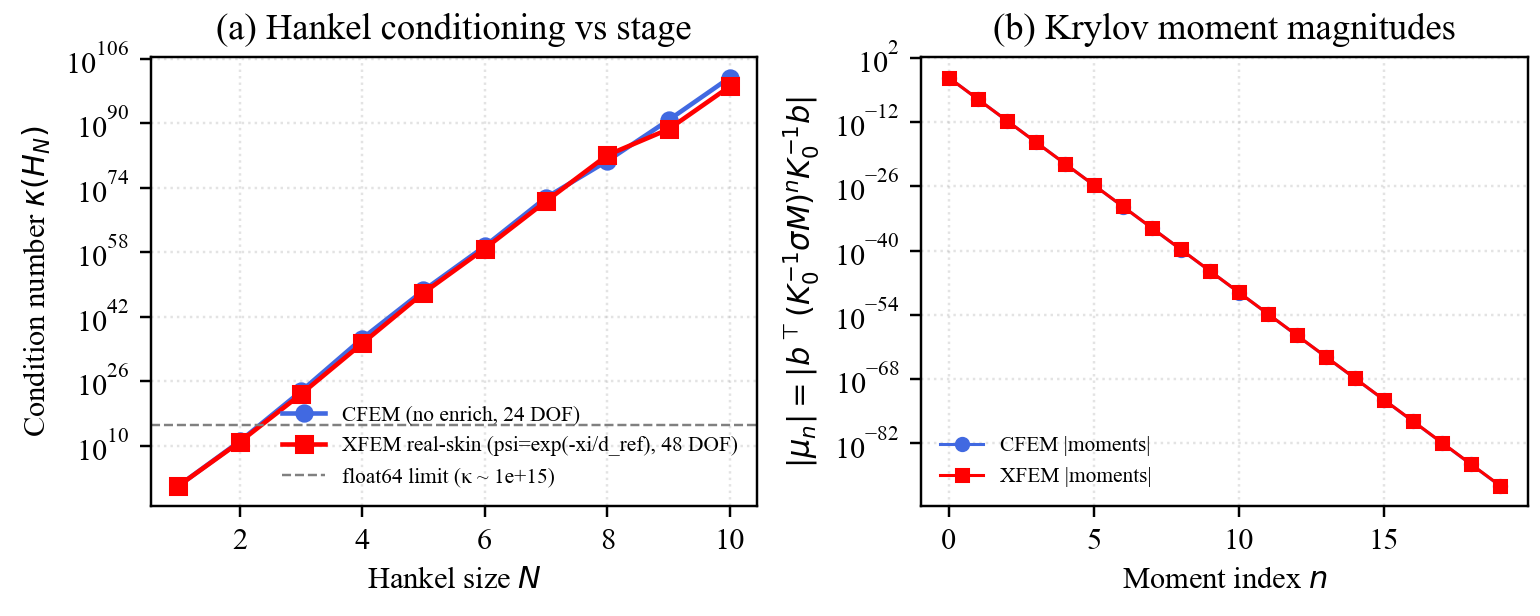

In [6]:
from IPython.display import Image
Image("phase4_xfem_hankel_conditioning.png")